<a href="https://colab.research.google.com/github/JavierPelao/Deep_Learning_Ev1/blob/main/Deep_Learning_Ev1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title
from IPython.display import HTML, display

url_svg = "https://upload.wikimedia.org/wikipedia/commons/a/aa/Logo_DuocUC.svg"

display(HTML(f'<img src="{url_svg}" width="300">'))

**Asignatura:** Deep Learning_004D       
**Evaluación:** Evaluación Parcial N°1  
**Integrantes:** Javier Loaiza - Fabian Romero  
**Fecha:** Septiembre 2026

# Evaluación Parcial 1 - Deep Learning

## Clasificación de imágenes con una Red Neuronal Multicapa (MLP)

### Introducción

En esta evaluación se desarrollará una red neuronal artificial multicapa (MLP) para resolver un problema de clasificación de imágenes utilizando el conjunto de datos Fashion-MNIST.

Fashion-MNIST contiene imágenes en escala de grises correspondientes a distintas categorías de prendas de vestir. A partir de estos datos, se busca entrenar una red neuronal capaz de aprender patrones presentes en las imágenes y posteriormente clasificarlas en su categoría correspondiente.

Durante el desarrollo se aplicarán conceptos estudiados en la asignatura, como funciones de activación, función de pérdida, descenso del gradiente, backpropagation, optimización y técnicas de regularización. Además, se analizará el comportamiento del modelo mediante distintas configuraciones de entrenamiento y métricas de evaluación.

### Objetivo

Implementar y entrenar una red neuronal multicapa (MLP) utilizando TensorFlow/Keras para clasificar imágenes del conjunto Fashion-MNIST, analizando el efecto de diferentes configuraciones y técnicas de entrenamiento sobre el desempeño y la capacidad de generalización del modelo.

## Carga del conjunto de datos

Para el desarrollo de la evaluación se utilizará el conjunto de datos Fashion-MNIST, disponible directamente a través de TensorFlow/Keras. El dataset contiene imágenes en escala de grises de distintas prendas de vestir, junto con la etiqueta correspondiente a cada imagen.

En esta primera etapa se cargarán los datos y se revisará su estructura antes de realizar cualquier transformación o preprocesamiento.

In [5]:
# Importar el dataset Fashion-MNIST desde Keras
from tensorflow.keras.datasets import fashion_mnist

# Cargar los conjuntos originales de entrenamiento y prueba
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Mostrar las dimensiones de los conjuntos cargados
print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_test:", y_test.shape)

Dimensiones de X_train: (60000, 28, 28)
Dimensiones de y_train: (60000,)
Dimensiones de X_test: (10000, 28, 28)
Dimensiones de y_test: (10000,)


### Estructura inicial de los datos

El conjunto de entrenamiento contiene 60.000 imágenes de 28×28 píxeles y 60.000 etiquetas asociadas. Por otra parte, el conjunto de prueba contiene 10.000 imágenes con sus respectivas etiquetas.

Las imágenes se encuentran almacenadas en `X_train` y `X_test`, mientras que `y_train` y `y_test` contienen las clases correspondientes a cada imagen.

El conjunto de prueba se mantendrá reservado para la evaluación final del modelo, evitando utilizarlo durante la selección y ajuste de configuraciones.

In [6]:
import numpy as np

# Revisar características básicas del conjunto de entrenamiento
print("Rango de valores de los píxeles:", X_train.min(), "-", X_train.max())
print("Tipo de dato:", X_train.dtype)
print("Clases presentes:", np.unique(y_train))
print("Cantidad de clases:", len(np.unique(y_train)))

Rango de valores de los píxeles: 0 - 255
Tipo de dato: uint8
Clases presentes: [0 1 2 3 4 5 6 7 8 9]
Cantidad de clases: 10


### Análisis inicial

Las imágenes presentan valores de píxeles en un rango de 0 a 255 y se encuentran almacenadas con tipo de dato `uint8`. Esta información será considerada posteriormente durante el preprocesamiento de los datos.

Las etiquetas corresponden a valores enteros entre 0 y 9, por lo que el problema presenta un total de 10 clases diferentes.

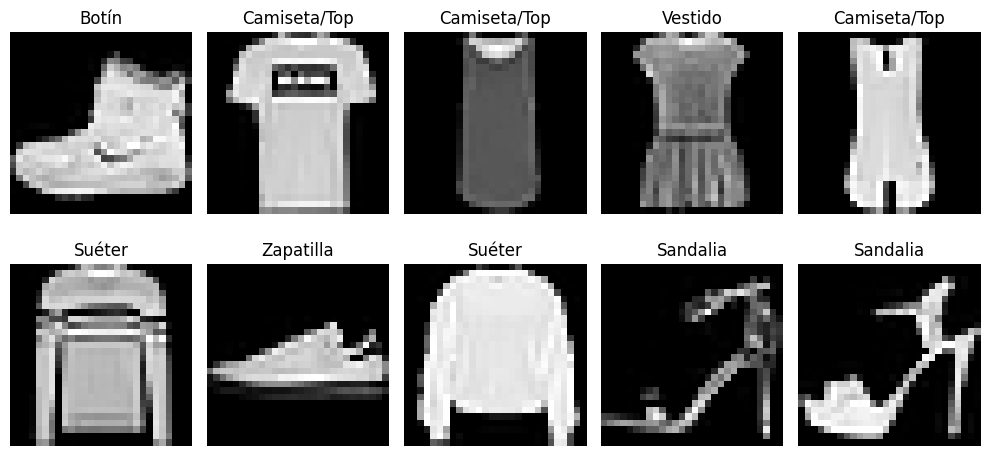

In [7]:
import matplotlib.pyplot as plt

# Nombres correspondientes a las 10 clases de Fashion-MNIST
class_names = [
    "Camiseta/Top", "Pantalón", "Suéter", "Vestido", "Abrigo",
    "Sandalia", "Camisa", "Zapatilla", "Bolso", "Botín"
]

# Visualizar las primeras 10 imágenes del conjunto de entrenamiento
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

### Visualización de ejemplos

Se visualizaron ejemplos del conjunto de entrenamiento junto con sus respectivas etiquetas para comprender la información contenida en Fashion-MNIST. Se observa que las imágenes corresponden a prendas de vestir representadas en escala de grises y con una resolución de 28×28 píxeles.

Las etiquetas originales se encuentran codificadas mediante valores enteros entre 0 y 9, por lo que para facilitar su interpretación se asociaron con los nombres de las clases definidos en español para asi poder identificar y explicar de manera clara los resultados.